In [33]:
# Load the libraries
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt

In [34]:
# Load the dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns = data.feature_names)
y = pd.Series(data.target)

In [35]:
# Shape of the data
print("Shape", X.shape)

Shape (569, 30)


In [36]:
# Value Counts
y.value_counts()

1    357
0    212
Name: count, dtype: int64

In [37]:
# Train test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify = y)

In [57]:
# Train a lightgbm model
# objective --> Tells lightgbm what type of problem you are solving
# metric --> evaluation metric lightgbm uses to measure model performance
model = lgb.LGBMClassifier(objective="binary", metric="binary_logloss", random_state=42)

In [58]:
model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000207 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [59]:
# Prediction + evaluation
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

In [60]:
print(preds)

[0 0 0 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 1 1 1
 0 1 1 0 1 0 1 1 0 0 0 1 1 0 1 0 0 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1
 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0
 1 1 1]


In [61]:
print(probs)

[1.08279633e-04 2.72880899e-05 1.02784438e-04 9.99919260e-01
 8.28343235e-04 9.99470486e-01 3.59288041e-05 9.99916003e-01
 9.99976541e-01 2.83762209e-05 5.42156446e-05 9.99962229e-01
 9.46671250e-01 9.99585863e-01 9.97184230e-01 2.67454054e-05
 2.73620688e-05 9.99983639e-01 2.68935786e-05 2.14305294e-04
 9.99980244e-01 4.94236508e-02 9.99917635e-01 9.99982978e-01
 9.99955351e-01 2.63034729e-05 2.69236887e-05 1.53905745e-01
 3.52577795e-05 9.97933457e-01 3.87566689e-05 9.99959061e-01
 2.54383064e-05 9.99966101e-01 9.99954401e-01 9.99972505e-01
 9.99983829e-01 4.52798461e-05 9.99978413e-01 9.99965919e-01
 3.68851261e-05 9.99976148e-01 6.92076769e-03 9.53684904e-01
 9.99968662e-01 3.80614450e-02 4.29560907e-01 2.27397114e-01
 9.99954396e-01 9.99980980e-01 2.55329084e-05 9.99766181e-01
 2.02044683e-04 6.95953292e-05 9.99952288e-01 9.99906181e-01
 9.98997701e-01 9.98820282e-01 3.19525860e-05 3.69992184e-05
 2.72382556e-05 9.99927149e-01 9.99978818e-01 9.99809208e-01
 9.98726456e-01 9.998929

In [62]:
print("\nAccuracy:", accuracy_score(y_test, preds))
print("\nROC AUC:", roc_auc_score(y_test, probs))
print("\nClassification report:")
print(classification_report(y_test, preds))


Accuracy: 0.9210526315789473

ROC AUC: 0.9778439153439153

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [63]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))


Confusion Matrix:
[[39  3]
 [ 6 66]]


In [64]:
# Hyperparameter Tuning (GridSearch CV)
param_grid = {
    'num_leaves': [15, 31, 50],
    'learning_rate': [0.1, 0.05],
    'n_estimators': [100, 300]
}

In [65]:
grid = GridSearchCV(
    estimator=lgb.LGBMClassifier(objective="binary", random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=0
)

In [66]:
grid.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 190, number of negative: 113
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000274 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3041
[LightGBM] [Info] Number of data points in the train set: 303, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.627063 -> initscore=0.519636
[LightGBM] [Info] Start training from score 0.519636
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,estimator,LGBMClassifie...ndom_state=42)
,param_grid,"{'learning_rate': [0.1, 0.05], 'n_estimators': [100, 300], 'num_leaves': [15, 31, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [67]:
print("\nBest parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)


Best parameters: {'learning_rate': 0.05, 'n_estimators': 300, 'num_leaves': 31}
Best CV accuracy: 0.9648541884512606


In [68]:
best_model = grid.best_estimator_

In [69]:
best_preds = best_model.predict(X_test)
best_probs = best_model.predict_proba(X_test)[:, 1]

In [70]:
print("\nAccuracy (best model):", accuracy_score(y_test, best_preds))
print("ROC AUC (best model):", roc_auc_score(y_test, best_probs))


Accuracy (best model): 0.9473684210526315
ROC AUC (best model): 0.9828042328042328


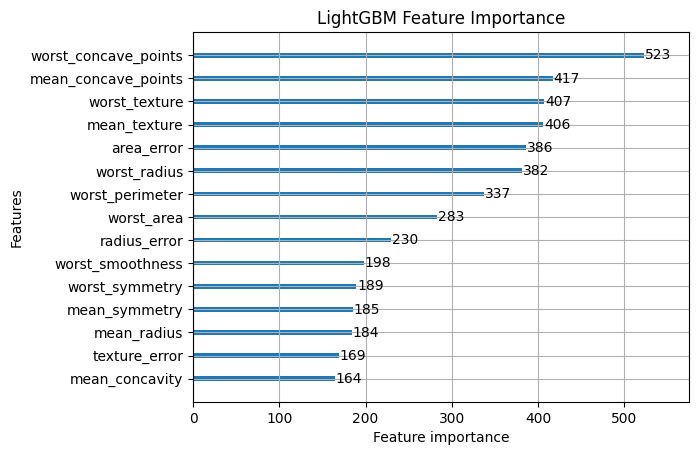

In [71]:
# Feature Importance
lgb.plot_importance(best_model, max_num_features=15)
plt.title("LightGBM Feature Importance")
plt.show()